# Deep learning models for arrhythmia detection and diagnosis

## Initialisation

In [1]:
# For colab
from google.colab import drive
drive.mount('/content/drive')
!pip install wfdb
!pip install pywavelets

Mounted at /content/drive
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 89.9/89.9 kB 9.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 163.8/163.8 kB 14.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.1/13.1 MB 69.0 MB/s eta 0:00:00
  Attempting uninstall: pandas
    Found existing installation: pandas 2.2.2
    Uninstalling pandas-2.2.2:
      Successfully uninstalled pandas-2.2.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 2.2.3 which is incompatible.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.5/4.5 MB 61.7 MB/s eta 0:00:00


In [2]:
# Imports
import os
from os.path import join as osj
import pandas as pd
import numpy as np
import torch
import wfdb
import pywt
import matplotlib.pyplot as plt
import math
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay
from imblearn.combine import SMOTETomek
from imblearn.over_sampling import SMOTE
from sklearn.utils import resample
from collections import Counter
# import optuna

# Directory where the dataset is stored
#dataset_directory = 'mit-bih-arrhythmia-database-1.0.0/'

# For colab
project_directory = '/content/drive/MyDrive/RAT-Net_ws/'
dataset_directory = project_directory + 'mit-bih-arrhythmia-database-1.0.0/'

# Initialise dictionaries and arrays to store data
lead1 = {}
lead2 = {}
signal_pairs = {}
annotations = {}

# Labels for non beats
non_beat_annotations = [
    '[',  # Start of ventricular flutter/fibrillation
    '!',  # Ventricular flutter wave
    ']',  # End of ventricular flutter/fibrillation
    'x',  # Non-conducted P-wave (blocked APC)
    '(',  # Waveform onset
    ')',  # Waveform end
    'p',  # Peak of P-wave
    't',  # Peak of T-wave
    'u',  # Peak of U-wave
    '`',  # PQ junction
    "'",  # J-point
    '^',  # Non-captured pacemaker artifact
    '|',  # Isolated QRS-like artifact
    '~',  # Change in signal quality
    '+',  # Rhythm change
    's',  # ST segment change
    'T',  # T-wave change
    '*',  # Systole
    'D',  # Diastole
    '=',  # Measurement annotation
    '"',  # Comment annotation
    '@'   # Link to external data
]

# Label map designed to map MIT-BIH labels into the AAMI classes
AAMI_classes = {
    # N class
    'N': 0, 'L': 0, 'R': 0, 'e': 0, 'j': 0, 'B': 0,
    # S class
    'A': 1, 'a': 1, 'J': 1, 'S': 1,
    # V class
    'V': 2, 'E': 2, 'r': 2,
    # F class
    'F': 3,
    # Q Class
    'f': 4, '/': 4, 'Q': 4, '?': 4
}

# Create a Dataset object to be used later for training and testing
class ECGDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(np.array(X), dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.long)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]


## Data Preprocessing

### Preprocessing functions

In [ ]:
def swt_denoise(signal_pair):
    """
    Denoises a pair of ECG signals using SWT with soft thresholding.

    Parameters:
        signal_pair (Tuple[np.ndarray, np.ndarray]): Pair of 1D signals.

    Returns:
        Tuple[np.ndarray, np.ndarray]: Denoised pair.
    """
    def _denoise(signal):
        # Decompose
        max_level = pywt.swt_max_level(len(signal))
        wavelet = "bior3.1"
        coeffs = pywt.swt(signal, wavelet, level=max_level)


        detail_coeffs = np.array(coeffs[0][1])
        sigma = np.median(np.abs(detail_coeffs)) / 0.6745
        threshold = sigma * np.sqrt(2 * np.log(len(signal)))

        # Threshold coefficients
        new_coeffs = []
        for approx, detail in coeffs:
            detail = pywt.threshold(detail, threshold, mode='soft')
            new_coeffs.append((approx, detail))

        # Reconstruct and return
        return pywt.iswt(new_coeffs, wavelet)

    lead1, lead2 = signal_pair[:, 0], signal_pair[:, 1]
    return _denoise(lead1), _denoise(lead2)

def standardise(signal_pair):
    """
    Standardises a pair of ECG signals.

    Parameters:
        signal_pair (Tuple[np.ndarray, np.ndarray]): Pair of 1D signals.

    Returns:
        Tuple[np.ndarray, np.ndarray]: Standardised signals.
    """
    def _standardise(signal):
        mean_val = np.mean(signal)
        std_val = np.std(signal)
        return (signal - mean_val) / std_val

    lead1, lead2 = signal_pair
    return _standardise(lead1), _standardise(lead2)

def segmentation_fixed_window(signal_pair, annotation, before=100, after=200):
    """
    Segments beats using a fixed window around each R-peak for both leads.

    Parameters:
        signal_pair (Tuple[np.ndarray, np.ndarray]): Tuple of 1D ECG signals (lead1, lead2).
        annotation (wfdb.Annotation): Annotation object with R-peaks.
        before (int): Number of samples before the R-peak.
        after (int): Number of samples after the R-peak.

    Returns:
        segments (List[np.ndarray]): List of 2x300 segments (2 leads).
        labels (List[str]): Corresponding beat labels.
    """
    lead1, lead2 = signal_pair
    r_peaks = annotation.sample
    r_labels = annotation.symbol

    segments = []
    labels = []

    for peak, label in zip(r_peaks, r_labels):
        start = peak - before
        end = peak + after

        # Ensure segment is within signal bounds
        if start < 0 or end > len(lead1):
            continue

        if label not in non_beat_annotations:
            seg1 = lead1[start:end]
            seg2 = lead2[start:end]
            segment = np.stack([seg1, seg2], axis=0) # Shape: [2, window_length]
            segments.append(segment)
            labels.append(AAMI_classes[label])

    return segments, labels

def process_signal(signal_pair, annotation):
    """
    Takes an id and returns the X, y for that id.

    Parameters:
        id (int): The id of the record.

    Returns:
        tuple: A tuple containing the segments and labels.
    """
    denoised_pair = swt_denoise(signal_pair)
    normalised_pair = standardise(denoised_pair)
    segmented_pair, y = segmentation_fixed_window(normalised_pair, annotation)

    X = np.array(segmented_pair)  # Convert to numpy array

    X = torch.tensor(X, dtype=torch.float32)

    y = torch.tensor(y, dtype=torch.long)

    return X, y

### Load data, apply processing to data and separate into train and testing

In [ ]:
# Get an array of all ids
# record_ids = pd.read_csv(os.path.join(dataset_directory, 'RECORDS'), header=None).to_numpy().reshape(-1)

# X = []
# y = []

# # Load the data
# for id in record_ids:
#     signal, info = wfdb.io.rdsamp(osj(dataset_directory, str(id)))
#     annotation = wfdb.rdann(dataset_directory + str(id), "atr")
#     X_i, y_i = process_signal(signal, annotation)
#     X.append(X_i)
#     y.append(y_i)
#     print(f'Loaded record: {id}')

# X = np.concatenate(X, axis=0)
# y = np.concatenate(y, axis=0)

# X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y)
# X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.15, stratify=y_train)

# X_train_flat = X_train.reshape(X_train.shape[0], -1)

# # Apply SMOTE to the flattened data
# smote_tomek = SMOTETomek(sampling_strategy='auto', smote=SMOTE(k_neighbors=5))
# X_train_resampled_flat, y_train_resampled = smote_tomek.fit_resample(X_train_flat, y_train)

# # Reshape back to the original shape if necessary
# X_train_resampled = X_train_resampled_flat.reshape(X_train_resampled_flat.shape[0], X_train.shape[1], X_train.shape[2])

# # Save data no need to rerun each time
# save_dir = project_directory + "data_splits"
# os.makedirs(save_dir, exist_ok=True)
# np.save(os.path.join(save_dir, "X_train.npy"), X_train_resampled)
# np.save(os.path.join(save_dir, "y_train.npy"), y_train_resampled)
# np.save(os.path.join(save_dir, "X_val.npy"), X_val)
# np.save(os.path.join(save_dir, "y_val.npy"), y_val)
# np.save(os.path.join(save_dir, "X_test.npy"), X_test)
# np.save(os.path.join(save_dir, "y_test.npy"), y_test)

Loaded record: 100
Loaded record: 101
Loaded record: 102
Loaded record: 103
Loaded record: 104
Loaded record: 105
Loaded record: 106
Loaded record: 107
Loaded record: 108
Loaded record: 109
Loaded record: 111
Loaded record: 112
Loaded record: 113
Loaded record: 114
Loaded record: 115
Loaded record: 116
Loaded record: 117
Loaded record: 118
Loaded record: 119
Loaded record: 121
Loaded record: 122
Loaded record: 123
Loaded record: 124
Loaded record: 200
Loaded record: 201
Loaded record: 202
Loaded record: 203
Loaded record: 205
Loaded record: 207
Loaded record: 208
Loaded record: 209
Loaded record: 210
Loaded record: 212
Loaded record: 213
Loaded record: 214
Loaded record: 215
Loaded record: 217
Loaded record: 219
Loaded record: 220
Loaded record: 221
Loaded record: 222
Loaded record: 223
Loaded record: 228
Loaded record: 230
Loaded record: 231
Loaded record: 232
Loaded record: 233
Loaded record: 234
Original y_train: Counter({np.int64(0): 61599, np.int64(4): 5466, np.int64(2): 4920, np.

## Model

In [ ]:
class ChannelAttention(nn.Module):
    def __init__(self, in_channels, reduction=16):
        super(ChannelAttention, self).__init__()
        self.fc1 = nn.Linear(in_channels, in_channels // reduction)
        self.fc2 = nn.Linear(in_channels // reduction, in_channels)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        avg_pool = torch.mean(x, dim=-1)
        max_pool, _ = torch.max(x, dim=-1)
        channel_attention = self.sigmoid(self.fc2(self.fc1(avg_pool)) + self.fc2(self.fc1(max_pool)))
        return x * channel_attention.unsqueeze(-1)

class SpatialAttention(nn.Module):
    def __init__(self, kernel_size=7):
        super(SpatialAttention, self).__init__()
        self.conv = nn.Conv1d(in_channels=2 , out_channels=1, kernel_size=kernel_size, padding=kernel_size//2)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        avg_pool = torch.mean(x, dim=1, keepdim=True)
        max_pool, _ = torch.max(x, dim=1, keepdim=True)
        x_att = torch.cat([avg_pool, max_pool], dim=1)
        x_att = self.sigmoid(self.conv(x_att))
        return x * x_att

class CBAMBlock(nn.Module):
    def __init__(self, channels, reduction=16, kernel_size=7):
        super(CBAMBlock, self).__init__()
        self.channel_attention = ChannelAttention(channels, reduction)
        self.spatial_attention = SpatialAttention(kernel_size)

    def forward(self, x):
        x = self.channel_attention(x)
        x = self.spatial_attention(x)
        return x

class ResidualBlock1D(nn.Module):
    def __init__(self, in_channels, out_channels, kernel_size=3, downsample=False, dropout=0.2):
        super(ResidualBlock1D, self).__init__()
        stride = 2 if downsample else 1
        padding = (kernel_size - 1) // 2
        self.conv1 = nn.Conv1d(in_channels, out_channels, kernel_size, stride=stride, padding=padding)
        self.bn1 = nn.BatchNorm1d(out_channels)
        self.relu = nn.ReLU(inplace=True)
        self.conv2 = nn.Conv1d(out_channels, out_channels, kernel_size, stride=1, padding=padding)
        self.bn2 = nn.BatchNorm1d(out_channels)
        self.cbam = CBAMBlock(out_channels)
        self.dropout = nn.Dropout(dropout)

        self.downsample = nn.Sequential()
        if downsample or in_channels != out_channels:
            self.downsample = nn.Sequential(
                nn.Conv1d(in_channels, out_channels, kernel_size=1, stride=stride),
                nn.BatchNorm1d(out_channels),
            )

    def forward(self, x):
        identity = self.downsample(x)
        x = self.relu(self.bn1(self.conv1(x)))
        x = self.bn2(self.conv2(x))
        x = self.cbam(x)
        x = self.dropout(x)
        x += identity
        return self.relu(x)

class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=5000):
        super(PositionalEncoding, self).__init__()
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        pe = pe.unsqueeze(1)
        self.register_buffer('pe', pe)

    def forward(self, x):
        x = x + self.pe[:x.size(0)]
        return x

class ResNet1D(nn.Module):
    def __init__(self, num_blocks=4, kernel_size=21, dropout=0.2):
        super(ResNet1D, self).__init__()
        layers = []
        in_channels = 2
        out_channels = 32
        current_size = 300 # Input size

        # Create residual blocks and calculate output size
        for i in range(num_blocks):
            downsample = i < num_blocks -1
            layers.append(ResidualBlock1D(in_channels, out_channels, kernel_size=kernel_size, downsample=downsample, dropout=dropout))
            in_channels = out_channels

            out_channels *= 2 # Double the outchannels each block

            # Calculate output size after this block
            if i > 0:  # Downsampling occurs after the first block
                current_size = (current_size - kernel_size + 2) // 2 + 1

        self.ResNet = nn.Sequential(*layers)

    def forward(self, x):
        x = self.ResNet(x)
        return x

class Transformer(nn.Module):
    def __init__(self, d_model=128, nhead=4, num_layers=2, dropout=0.2):
        super(Transformer, self).__init__()
        encoder_layer = nn.TransformerEncoderLayer(d_model=d_model, nhead=nhead, dropout=dropout, norm_first=True)
        self.transformer_encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_layers, enable_nested_tensor=False)
        self.position_encoding = PositionalEncoding(d_model)

    def forward(self, x):
        x = self.position_encoding(x)
        return self.transformer_encoder(x)

class Classifier(nn.Module):
    def __init__(self, shape=[128, 5], dropout=0.2):
        super(Classifier, self).__init__()
        layers = []
        # Input dim is the first size in shape
        input_dim = shape[0]
        output_dim = shape[-1]

        # Iterate through shape, excluding the final layer
        for layer_size in shape[1:-1]:
            layers.extend([
                nn.Linear(input_dim, layer_size),
                nn.ReLU(),
                nn.Dropout(dropout)
            ])
            input_dim = layer_size

        # Handle output layer
        layers.append(nn.Linear(input_dim, output_dim))
        self.classifier = nn.Sequential(*layers)

    def forward(self, x):
        return self.classifier(x)

class RATNet(nn.Module):
    def __init__(self, num_classes=5, dropout=0.2):
        super(RATNet, self).__init__()
        # Define ResNet blocks (Input size is assumed 300, Output is 32)
        self.ResNet = ResNet1D(num_blocks=5, dropout=dropout)
        # Define transfomer (d model is depednant on the number of layers)
        self.transformer = Transformer(d_model=128, nhead=4, num_layers=1, dropout=dropout)
        # Define classifier (shape = [first layer(input dim), hiddenlayers, output layer(numclasses)])
        self.classifier = Classifier(shape=[128, 128, num_classes], dropout=dropout)

    def forward(self, x):
        x = self.ResNet(x)
        x = x.permute(2,0,1)
        x = self.transformer(x)
        x = x.mean(dim=0)
        x = self.classifier(x)
        return x

## Training

### Training Parameters

In [ ]:
# MPS does not work
# if torch.backends.mps.is_available():
#     device = torch.device("mps")

if torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")

print(device)

epochs = 10
batch_size = 128
learning_rate = 1e-4
weight_decay = 1e-5

train_dataset = ECGDataset(X_train_resampled, y_train_resampled)
test_dataset = ECGDataset(X_test, y_test)
validation_dataset = ECGDataset(X_val, y_val)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)
validation_loader = DataLoader(validation_dataset, batch_size=batch_size, shuffle=False)

model = RATNet().to(device)
optimiser = optim.AdamW(model.parameters(), lr=learning_rate) # weight_decay=weight_decay
# scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimiser, mode='min', factor=0.5, patience=3)
criterion = nn.CrossEntropyLoss()

cuda


### Training loop

In [ ]:
for epoch in range(epochs):
    # Training phase
    model.train()
    total_loss, correct, total = 0, 0, 0

    for inputs, labels in train_loader:
        inputs = inputs.to(device)
        labels = labels.to(device)

        optimiser.zero_grad()
        outputs = model(inputs)

        loss = criterion(outputs, labels)
        loss.backward()
        optimiser.step()

        total_loss += loss.item() * inputs.size(0)
        _, predicted = torch.max(outputs, 1)
        correct += (predicted == labels).sum().item()
        total += labels.size(0)

    train_loss = total_loss / total
    train_acc = correct / total

    # Validation phase
    model.eval()  # Set the model to evaluation mode
    val_loss, val_correct, val_total = 0, 0, 0

    with torch.no_grad():  # No gradients are computed during validation
        for inputs, labels in validation_loader:
            inputs = inputs.to(device)
            labels = labels.to(device)

            outputs = model(inputs)
            loss = criterion(outputs, labels)

            val_loss += loss.item() * inputs.size(0)
            _, predicted = torch.max(outputs, 1)
            val_correct += (predicted == labels).sum().item()
            val_total += labels.size(0)

    val_loss = val_loss / val_total
    val_acc = val_correct / val_total

    #scheduler.step(val_loss)

    print(f"Epoch {epoch+1}/{epochs} - "
            f"Train Loss: {train_loss:.4f} - Train Acc: {train_acc:.4f} - "
            f"Val Loss: {val_loss:.4f} - Val Acc: {val_acc:.4f}")


KeyboardInterrupt: 

## Testing

Test Accuracy:     99.0498
Test Precision:    93.9842
Test Recall:       95.0773
Test F1 Score:     94.5213
Confusion Matrix (Test):


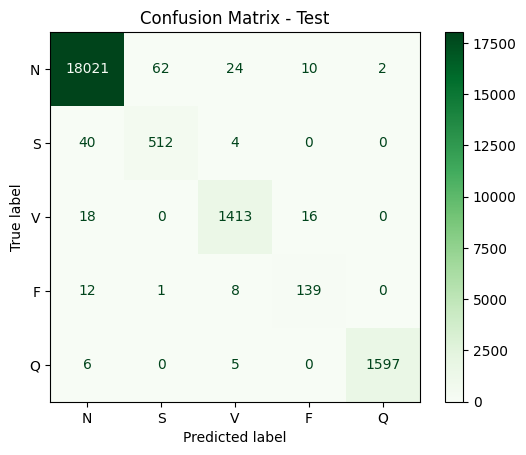

In [ ]:
model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for inputs, labels in test_loader:
        inputs = inputs.to(device)
        labels = labels.to(device)

        outputs = model(inputs)
        _, predicted = torch.max(outputs, 1)

        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

acc = accuracy_score(all_labels, all_preds)
precision = precision_score(all_labels, all_preds, average='macro', zero_division=0)
recall = recall_score(all_labels, all_preds, average='macro', zero_division=0)
f1 = f1_score(all_labels, all_preds, average='macro', zero_division=0)


print(f"Test Accuracy:     {acc*100:.4f}") # average=None?
print(f"Test Precision:    {precision*100:.4f}")
print(f"Test Recall:       {recall*100:.4f}")
print(f"Test F1 Score:     {f1*100:.4f}")

print("Confusion Matrix (Test):")
cm_test = confusion_matrix(all_labels, all_preds)
cm_test_disp = ConfusionMatrixDisplay(confusion_matrix=cm_test, display_labels=['N', 'S', 'V', 'F', 'Q'])
cm_test_disp.plot(cmap=plt.cm.Greens)
plt.title("Confusion Matrix - Test")
plt.show()

In [ ]:
# torch.save(model.state_dict(), '/content/drive/MyDrive/trained_model.pth')

# Testing but better

In [ ]:
lr = 1e-4
batch_size = 128

if torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")

print(device)


train_dataset = ECGDataset(X_train_resampled, y_train_resampled)
test_dataset = ECGDataset(X_test, y_test)
validation_dataset = ECGDataset(X_val, y_val)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)
validation_loader = DataLoader(validation_dataset, batch_size=batch_size, shuffle=False)

def test_model_configurations(train_loader, validation_loader, device, epochs=10):
    # Define the different configurations to test
    config_options = [
        (3, 15), (3, 21), (3, 25), (3, 31),
        (4, 15), (4, 21), (4, 25), (4, 31),
        (5, 15), (5, 21), (5, 25), (5, 31),
        (6, 15), (6, 21), (6, 25), (6, 31)

    ]

    # Store F1 scores for each configuration
    f1_scores = {}

    for num_blocks, kernel_size in config_options:
        print(f"Testing configuration: {num_blocks} blocks, kernel size {kernel_size}")

        # Initialize the model with the current configuration
        model = RATNet(num_classes=5, dropout=0.2)

        model.ResNet = ResNet1D(num_blocks=num_blocks, kernel_size=kernel_size, dropout=0.2)

        if num_blocks == 2:
            model.transformer = Transformer(d_model=64, nhead=4, num_layers=1, dropout=0.2)
            model.classifier = Classifier(shape=[64, 128, 5], dropout=0.2)
        if num_blocks == 3:
            model.transformer = Transformer(d_model=128, nhead=4, num_layers=1, dropout=0.2)
            model.classifier = Classifier(shape=[128, 128, 5], dropout=0.2)
        if num_blocks == 4:
            model.transformer = Transformer(d_model=256, nhead=4, num_layers=1, dropout=0.2)
            model.classifier = Classifier(shape=[256, 128, 5], dropout=0.2)
        if num_blocks == 5:
            model.transformer = Transformer(d_model=512, nhead=4, num_layers=1, dropout=0.2)
            model.classifier = Classifier(shape=[512, 128, 5], dropout=0.2)
        if num_blocks == 6:
            model.transformer = Transformer(d_model=1024, nhead=4, num_layers=1, dropout=0.2)
            model.classifier = Classifier(shape=[1024, 128, 5], dropout=0.2)

        model.to(device)  # Ensure the model is on the correct device

        optimiser = torch.optim.Adam(model.parameters(), lr=lr)
        criterion = nn.CrossEntropyLoss()

        # Training phase
        for epoch in range(epochs):
            model.train()
            total_loss, correct, total = 0, 0, 0

            for inputs, labels in train_loader:
                inputs = inputs.to(device)
                labels = labels.to(device)

                optimiser.zero_grad()
                outputs = model(inputs)

                loss = criterion(outputs, labels)
                loss.backward()
                optimiser.step()

                total_loss += loss.item() * inputs.size(0)
                _, predicted = torch.max(outputs, 1)
                correct += (predicted == labels).sum().item()
                total += labels.size(0)

            train_loss = total_loss / total
            train_acc = correct / total

        # Validation phase
        model.eval()
        val_loss, val_correct, val_total = 0, 0, 0
        all_preds = []
        all_labels = []

        with torch.no_grad():
            for inputs, labels in validation_loader:
                inputs = inputs.to(device)
                labels = labels.to(device)

                outputs = model(inputs)
                loss = criterion(outputs, labels)

                val_loss += loss.item() * inputs.size(0)
                _, predicted = torch.max(outputs, 1)
                val_correct += (predicted == labels).sum().item()
                val_total += labels.size(0)

                all_preds.extend(predicted.cpu().numpy())
                all_labels.extend(labels.cpu().numpy())

        val_loss = val_loss / val_total
        val_acc = val_correct / val_total

        # Calculate F1 score
        f1 = f1_score(all_labels, all_preds, average="macro")
        f1_scores[(num_blocks, kernel_size)] = f1

        print(f"Configuration: {num_blocks} blocks, kernel size {kernel_size} - "
              f"Val Loss: {val_loss:.4f} - Val Acc: {val_acc:.4f} - F1 Score: {f1:.4f}")

    return f1_scores

f1_scores = test_model_configurations(train_loader, validation_loader, device, epochs=10)

cuda
Testing configuration: 3 blocks, kernel size 15
Configuration: 3 blocks, kernel size 15 - Val Loss: 0.0473 - Val Acc: 0.9908 - F1 Score: 0.9484
Testing configuration: 3 blocks, kernel size 21
Configuration: 3 blocks, kernel size 21 - Val Loss: 0.0432 - Val Acc: 0.9909 - F1 Score: 0.9483
Testing configuration: 3 blocks, kernel size 25
Configuration: 3 blocks, kernel size 25 - Val Loss: 0.0672 - Val Acc: 0.9836 - F1 Score: 0.9027
Testing configuration: 3 blocks, kernel size 31
Configuration: 3 blocks, kernel size 31 - Val Loss: 0.0448 - Val Acc: 0.9914 - F1 Score: 0.9509
Testing configuration: 4 blocks, kernel size 15
Configuration: 4 blocks, kernel size 15 - Val Loss: 0.0430 - Val Acc: 0.9909 - F1 Score: 0.9424
Testing configuration: 4 blocks, kernel size 21
Configuration: 4 blocks, kernel size 21 - Val Loss: 0.0403 - Val Acc: 0.9925 - F1 Score: 0.9587
Testing configuration: 4 blocks, kernel size 25
Configuration: 4 blocks, kernel size 25 - Val Loss: 0.0398 - Val Acc: 0.9919 - F1 S

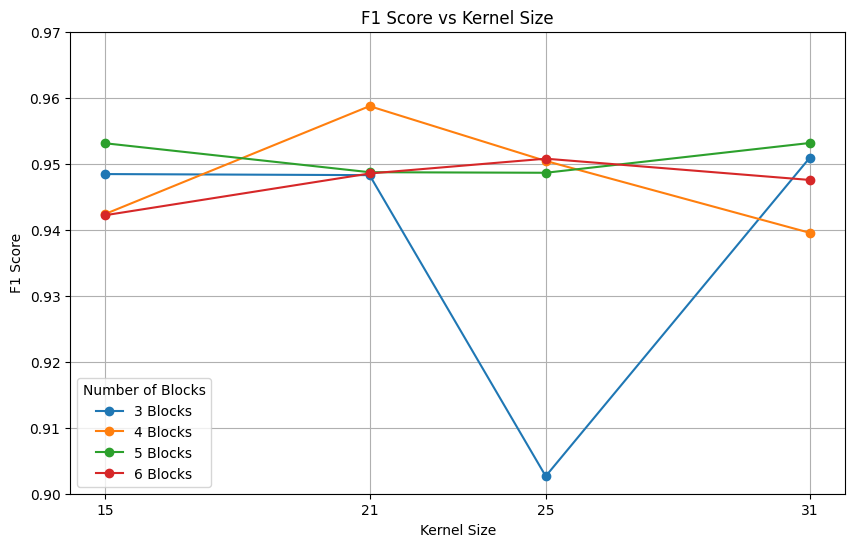

In [ ]:
def plot_f1_scores(f1_scores):
    """
    f1_scores: dictionary where keys are (num_blocks, kernel_size) and values are F1 scores
    """

    # Organize scores by number of blocks
    blocks_data = {}

    for (num_blocks, kernel_size), f1 in f1_scores.items():
        if num_blocks not in blocks_data:
            blocks_data[num_blocks] = {'kernel_sizes': [], 'f1_scores': []}
        blocks_data[num_blocks]['kernel_sizes'].append(kernel_size)
        blocks_data[num_blocks]['f1_scores'].append(f1)

    # Plot
    plt.figure(figsize=(10, 6))

    for num_blocks, data in sorted(blocks_data.items()):
        # Sort by kernel size
        sorted_data = sorted(zip(data['kernel_sizes'], data['f1_scores']))
        kernel_sizes, f1s = zip(*sorted_data)

        plt.plot(kernel_sizes, f1s, marker='o', label=f"{num_blocks} Blocks")

    plt.title('F1 Score vs Kernel Size')
    plt.xlabel('Kernel Size')
    plt.ylabel('F1 Score')
    plt.legend(title="Number of Blocks")
    plt.grid(True)
    plt.xticks([15, 21, 25, 31])  # Since your kernel sizes are these
    plt.ylim(0.9, 0.97)
    plt.show()

plot_f1_scores(f1_scores)